In [3]:
print("Hello World")

Hello World


In [4]:
# Importing necessary libraries
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

Pandas helps us put our data into neat dataframes
Numpy helps in the mathematical aspects of the project
sklearn helps us bring MSE and R2 score, both of which make our task easier instead of raw coding from scratch
matplotlib helps with plotting graphs and charts. Seaborn can also be used as it will be seen later.

In [5]:
# Bringing the datasets

# I have sifted through all the datasets i collected such that i got only those which contained both weather related features and crop yield features
# Remember, i have labelled them "st" to mean start, coz this is the messy data
st1 = pd.read_csv(r"C:\Users\Danny Excellcia\Desktop\Data Science\Datasets\df_yield_merged.csv")
df1 = pd.DataFrame(st1)

st2 = pd.read_csv(r"C:\Users\Danny Excellcia\Desktop\Data Science\Datasets\europe_cereal_yield_climate_1990_2022.csv")
df2 = pd.DataFrame(st2)

st3 = pd.read_excel(r"C:\Users\Danny Excellcia\Desktop\Data Science\Datasets\potential-impacts-world-food-supply.xls")
df3 = pd.DataFrame(st3)

st4 = pd.read_csv(r"C:\Users\Danny Excellcia\Desktop\Data Science\Datasets\project Dataset4.csv")
df4 = pd.DataFrame(st4)



In [6]:

# I can check the number of missing values in order to know the type of missingness
df3.isna().sum()
# My third dataset has more than half missing values. 
# Thus the dataset can be removed completely as this is MNAR (Missing Not At Random)


# Calling df1,df2,df3 & df4 will bring out a neat, well-arranged Dataframe

Unnamed: 0                                                                     53
Potential Impacts of Climate Change on World Food Supply, v 1 (1995 – 2110)    18
dtype: int64

In [7]:
# FOR DOUBLE CONFIRMATION PURPOSES

# Removing the missing values present in out datasets
# "cl" here means "clean" since the missing values are removed
cl1 = df1.dropna()
cl2 = df2.dropna()
cl4 = df4.dropna()

# CONFIRMATION
print(cl1.isna().sum())
print(cl2.isna().sum())
print(cl4.isna().sum())
# Thus, there are no missing values in my data



area                             0
year                             0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
item                             0
value_hg_ha                      0
dtype: int64
AREA                   0
ITEM                   0
YEAR                   0
YIELD                  0
AREA_HARVESTED         0
PRODUCTION_QUANTITY    0
WB_CCKP_CDD            0
WB_CCKP_CDD65          0
WB_CCKP_CSDI           0
WB_CCKP_CWD            0
WB_CCKP_FD             0
WB_CCKP_HD30           0
WB_CCKP_HD35           0
WB_CCKP_HD40           0
WB_CCKP_HD42           0
WB_CCKP_HD45           0
WB_CCKP_HD50           0
WB_CCKP_HDD65          0
WB_CCKP_HI35           0
WB_CCKP_HI37           0
WB_CCKP_HI39           0
WB_CCKP_HI41           0
WB_CCKP_HURS           0
WB_CCKP_ID             0
WB_CCKP_PR             0
WB_CCKP_R20MM          0
WB_CCKP_R50MM          0
WB_CCKP_R95PTOT        0
WB_CCKP_RX1DAY         0
WB_CCKP_RX5DAY   

In [8]:
# Initial Splitting but not with the goal to train
# I have put every dataset into 100 rows each
# "ds" basically means dataset
ds1 = cl1.head(99)
ds2 = cl1.iloc[100:199]
ds3 = cl1.iloc[214:313]
ds4 = cl1.iloc[378:477]
ds5 = cl1.iloc[746:845]
ds6 = cl1.iloc[810:909]
ds7 = cl1.iloc[1176:1275]

In [9]:
# EDA concept 
# Here I am basically exploring my data. I had divided my initial data into 7 portions but I only needed 2. It is those 2 datasets that i will use to find the best overall method.
import seaborn as sns
ds1.describe()
ds2.describe()

ds1.shape
ds2.shape


(99, 7)

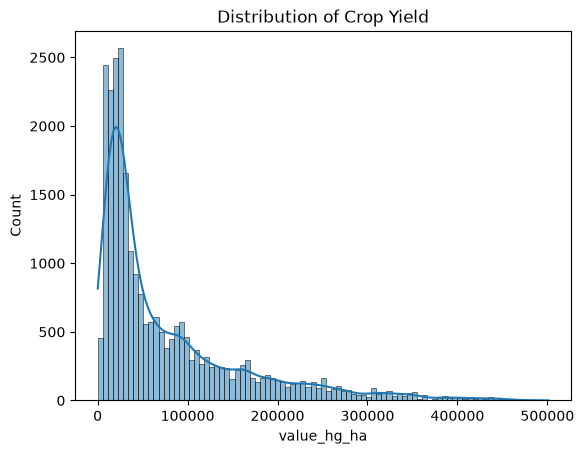

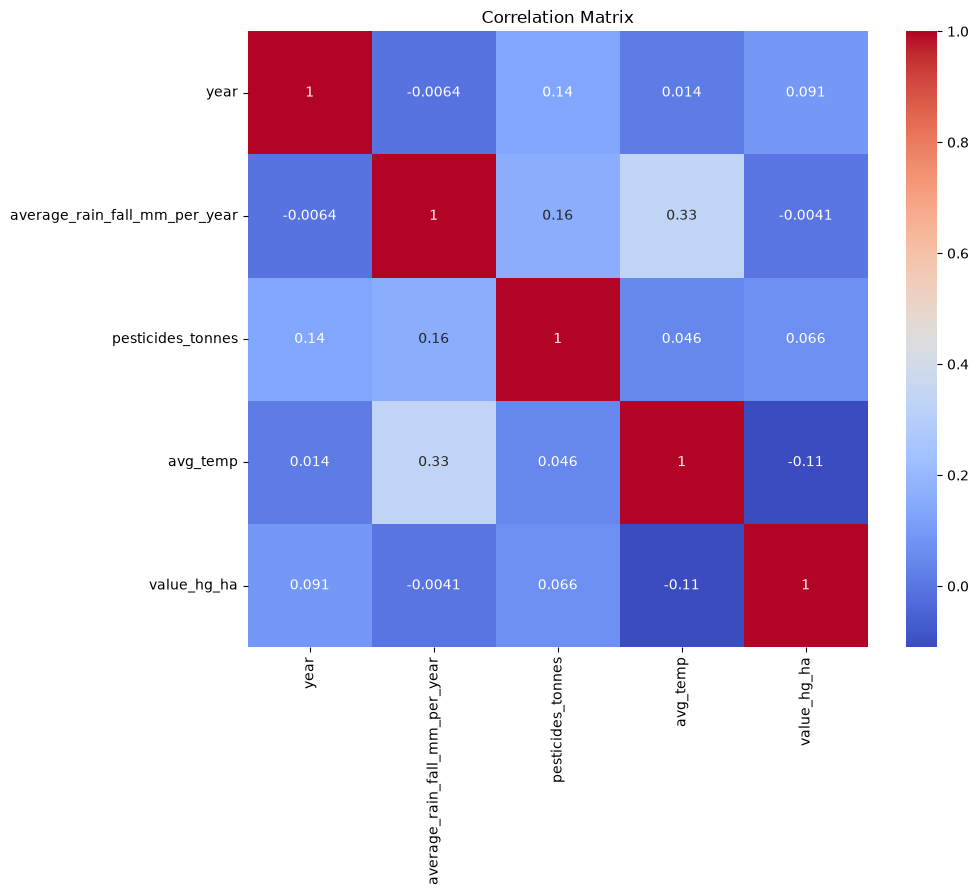

In [10]:
# Here my data correlations and relationship are visuallized using a heatmap

sns.histplot(df1['value_hg_ha'], kde=True)
plt.title('Distribution of Crop Yield')
plt.show()

# Correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm')  # Had to insert numeric_only since my data contain string values, "Country Names"
plt.title('Correlation Matrix')
plt.show()

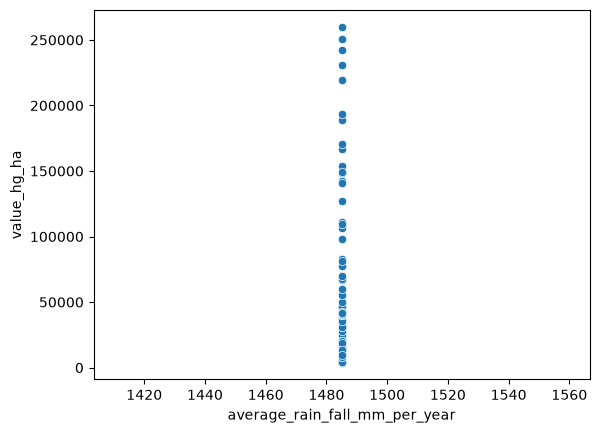

In [11]:

# Check if the relationship is curved
sns.scatterplot(x=ds1['average_rain_fall_mm_per_year'], y=ds1['value_hg_ha'])
plt.show()

In [12]:
# Hypothesis Testing:
from scipy import stats


In [13]:

# The null hypothesis is that: There is a low-no relationship between crop yields and rainfall / temperature.
# Here we want to see if we are wrong or right.

# Correlation Between Rainfall and crop yields
correlation, p_value = stats.pearsonr(df1['average_rain_fall_mm_per_year'], df1['value_hg_ha'])
print(f"Correlation(Rainfall & Yield): {correlation}, P-value(Rainfall & Yield): {p_value}")

corr, p_val = stats.pearsonr(df1["avg_temp"], df1['value_hg_ha'])
print(f"Correlation(Temp & Yield): {corr}, P_val(Temp & Yield): {p_val}")


Correlation(Rainfall & Yield): -0.004067097433402561, P-value(Rainfall & Yield): 0.5125239323144777
Correlation(Temp & Yield): -0.11039982443022328, P_val(Temp & Yield): 4.002191748419015e-71


In [14]:

# In the case of non-linear data, it is safer to use Spearman's correlation Matrix
from scipy.stats import spearmanr


In [15]:

tdata = df1[["average_rain_fall_mm_per_year","avg_temp","value_hg_ha"]]
corr1 = tdata.corr(method="spearman")
print(corr1)

# If p < 0.05, we reject the null hypothesis and say the relationship is significant.

                               average_rain_fall_mm_per_year  avg_temp  \
average_rain_fall_mm_per_year                       1.000000  0.313772   
avg_temp                                            0.313772  1.000000   
value_hg_ha                                         0.065701 -0.101484   

                               value_hg_ha  
average_rain_fall_mm_per_year     0.065701  
avg_temp                         -0.101484  
value_hg_ha                       1.000000  


In [16]:
idx1 = np.random.permutation(len(ds1))
cut1 = int(0.8 * len(ds1))

In [17]:
# Defining target features
X = ds1.drop(columns= ["area", "year", "pesticides_tonnes","item", "value_hg_ha"])
y = ds1["value_hg_ha"]
Xtr_raw, Xte_raw = X.iloc[idx1[:cut1]], X.iloc[idx1[cut1:]]
ytr, yte = y[idx1[:cut1]], y[idx1[cut1:]]


In [18]:
# This is another way of doing Linear Regression, with lesser methods required
from sklearn.linear_model import LinearRegression


In [19]:
# The training phase: Using Linear Regression
linear = LinearRegression()
linear.fit(Xtr_raw, ytr)

prediction = linear.predict(Xte_raw)



In [20]:
# Checking the MSE and R2 score
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
print(f"R2 score: {r2_score(yte, prediction)}")
print(f"MSE: {mean_squared_error(yte, prediction)}")

R2 score: 0.006121865623666678
MSE: 5435444906.99689


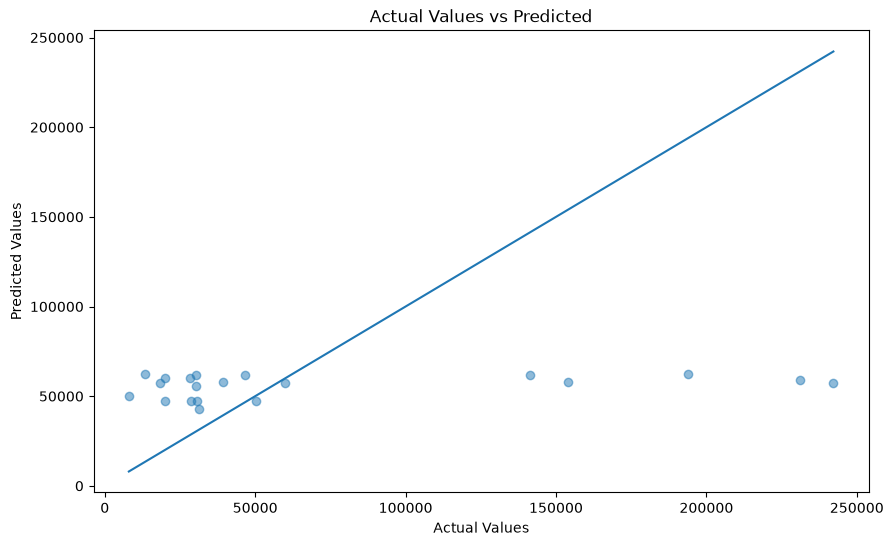

None


In [22]:
def visuallizing(yte, prediction):
    plt.figure(figsize= (10,6))
    plt.scatter(yte, prediction, alpha=0.5)
    plt.plot([yte.min(), yte.max()], [yte.min(), yte.max()])
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Actual Values vs Predicted")
    plt.show()

print(visuallizing(yte, prediction))

In [23]:


# 1. Initialize the Scaler
# Note: We initialize it here, but we will fit it on training data only later

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [24]:
# FIX: use the full cleaned dataset (cl1) instead of a 99-row slice, so the model has far more data to learn from
idx2 = np.random.permutation(len(cl1))
cut2 = int(0.8 * len(cl1))


In [25]:
# FIX: keep pesticides_tonnes as a numeric feature (it is a real yield driver, not an identifier column)
# FIX: one-hot encode "area" and "item" instead of dropping them, so country/crop signal is retained
X2 = cl1.drop(columns=["year", "value_hg_ha"])
X2 = pd.get_dummies(X2, columns=["area", "item"], drop_first=True)
y2 = cl1["value_hg_ha"]

Xtr_raw2, Xte_raw2 = X2.iloc[idx2[:cut2]], X2.iloc[idx2[cut2:]]
ytr2, yte2 = y2.iloc[idx2[:cut2]], y2.iloc[idx2[cut2:]]


In [26]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=5, min_samples_split=10, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0),
    "SVR": SVR(kernel='rbf', C=100, gamma='scale'),
    "MLP": MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42, early_stopping=True)
}

# Scaled versions of the training/test features (used for all models in the loop below)
sctr = scaler.fit_transform(Xtr_raw2)
scte = scaler.transform(Xte_raw2)


In [27]:
def train(name, model, Xtr_raw2, ytr2, Xte_raw2, yte2):
# The training bit
    model.fit(Xtr_raw2, ytr2)
# The prediction bit
    prediction2 = model.predict(Xte_raw2)
# Evaluating 
    MSE2 = mean_squared_error(yte2, prediction2)
    RMSE2 = np.sqrt(MSE2)
    r2_val = r2_score(yte2, prediction2)  # renamed to avoid shadowing the r2_score function

# After a short research
    if name in ["XGBoost"]:
        print(f"  -> Feature Importance Analysis:")
        importances = model.feature_importances_
        features = Xtr_raw2.columns
        sorted_idx = np.argsort(importances)[::-1]
        for i in sorted_idx:
            print(f"     {features[i]}: {importances[i]:.4f}")

def visuallize(name, yte, prediction, r2, rmse, mse):
    plt.figure(figsize=(10, 7))

    # Further research on how to use scatterplots
    sns.scatterplot(x=yte, y=prediction, alpha=0.6, color="blue", edgecolor="k", s=60)
    min_val = min(yte.min(), prediction.min())
    max_val = max(yte.max(), prediction.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit (y=x)')

    plt.xlabel("Actual Yield", fontsize=12, fontweight='bold')
    plt.ylabel("Predicted Yield", fontsize=12, fontweight='bold')
    
    title_text = f"{name} Performance\n"
    title_text += f"R² = {r2:.4f} | RMSE = {rmse:.4f} | MSE = {mse:.4f}"
    plt.title(title_text, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle=':')
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


In [ ]:
results = []

for name, model in models.items():
    model.fit(sctr, ytr2)             
    prediction = model.predict(scte)  
    mse = mean_squared_error(yte2, prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(yte2, prediction)
    results.append({"Model": name,
                    "MSE": mse,
                    "RMSE": rmse,
                    "R2 Score": r2})
    print(f"Model: {name}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.4f}")  # FIX: moved inside loop so every model prints

neat_res = pd.DataFrame(results)

# The best model is that with the highest R2 score


Model: Random Forest, MSE: 2278116022.04, RMSE: 47729.61, R2 Score: 0.6852
Model: XGBoost, MSE: 531964064.00, RMSE: 23064.35, R2 Score: 0.9265
Model: SVR, MSE: 7352598719.63, RMSE: 85747.30, R2 Score: -0.0159
Model: MLP, MSE: 397886894.91, RMSE: 19947.10, R2 Score: 0.9450
